In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path

In [14]:
# --- 1. CONFIGURACIÓN DE RUTAS (Compatible Windows/Linux) ---
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data" / "raw" / "waste_classification" / "test"
MODELS_DIR = BASE_DIR / "models"
MODEL_PATH = MODELS_DIR / "modelo_residuos_rpi_03.keras"
FIGURES_DIR = BASE_DIR / "reports" / "figures"

In [15]:
# Verificamos que existan
if not DATA_DIR.exists():
    raise FileNotFoundError(f"No se encontraron los datos en: {DATA_DIR}")
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"No se encontró el modelo en: {MODEL_PATH}. ¡Ejecuta el entrenamiento primero!")

print(f"Rutas verificadas.")
print(f"Cargando modelo desde: {MODEL_PATH}")

Rutas verificadas.
Cargando modelo desde: ../models/modelo_residuos_rpi_03.keras


In [16]:
# --- 2. CARGA DEL MODELO ---
model = load_model(MODEL_PATH)
print("Modelo cargado exitosamente.")

Modelo cargado exitosamente.


In [17]:
# --- 3. PREPARACIÓN DE DATOS (Solo Validación) ---
# Usamos las mismas dimensiones que en el entrenamiento
IMG_SIZE = (224, 224)
BATCH_SIZE = 16 # Podemos usar un batch más grande para inferencia

# Solo necesitamos re-escalar, no hacemos Data Augmentation para evaluar
datagen = ImageDataGenerator(
    rescale=1./255
)

print("Generando set de validación...")
test_gen = datagen.flow_from_directory(
    str(DATA_DIR),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # ¡IMPORTANTE! No mezclar para que coincidan las etiquetas con la predicción
)

class_labels = list(test_gen.class_indices.keys())
print(f"Clases detectadas: {len(class_labels)}")

Generando set de validación...
Found 5812 images belonging to 5 classes.
Clases detectadas: 5


In [18]:
print("Evaluando el modelo con los datos de prueba...")
loss, accuracy = model.evaluate(test_gen)

print(f"\nResultados Finales:")
print(f"   Pérdida (Loss): {loss:.4f}")
print(f"   Precisión (Accuracy): {accuracy*100:.2f}%")

Evaluando el modelo con los datos de prueba...
364/364 ━━━━━━━━━━━━━━━━━━━━ 107s 284ms/step - accuracy: 0.9849 - loss: 0.0588

Resultados Finales:
   Pérdida (Loss): 0.0588
   Precisión (Accuracy): 98.49%


Generando predicciones detalladas...
364/364 ━━━━━━━━━━━━━━━━━━━━ 103s 280ms/step


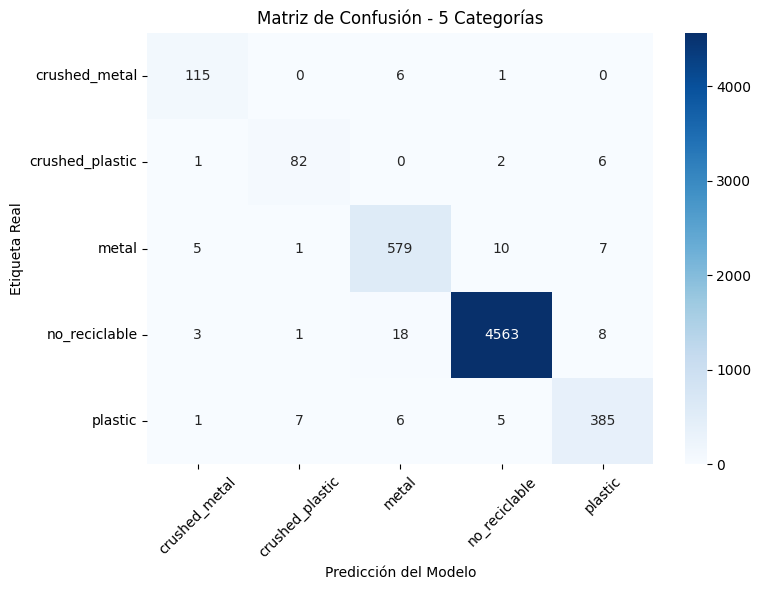


Reporte de Clasificación Detallado:
                 precision    recall  f1-score   support

  crushed_metal       0.92      0.94      0.93       122
crushed_plastic       0.90      0.90      0.90        91
          metal       0.95      0.96      0.96       602
  no_reciclable       1.00      0.99      0.99      4593
        plastic       0.95      0.95      0.95       404

       accuracy                           0.98      5812
      macro avg       0.94      0.95      0.95      5812
   weighted avg       0.98      0.98      0.98      5812



In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Generando predicciones detalladas...")
predictions = model.predict(test_gen)
y_pred = np.argmax(predictions, axis=1) # Tomamos la clase con mayor probabilidad
y_true = test_gen.classes               # Las etiquetas reales

# Obtenemos los nombres de tus 5 clases automáticamente
class_names = list(test_gen.class_indices.keys())

# --- MATRIZ DE CONFUSIÓN ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Matriz de Confusión - 5 Categorías')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.xticks(rotation=45)
plt.tight_layout()
save_path = FIGURES_DIR / "matriz_confusion.png"
plt.savefig(save_path, dpi=300)
plt.show()

# --- REPORTE DE CLASIFICACIÓN ---
print("\nReporte de Clasificación Detallado:")
print(classification_report(y_true, y_pred, target_names=class_names))

In [25]:
print(cm)

[[ 115    0    6    1    0]
 [   1   82    0    2    6]
 [   5    1  579   10    7]
 [   3    1   18 4563    8]
 [   1    7    6    5  385]]


Generando predicciones detalladas...
364/364 ━━━━━━━━━━━━━━━━━━━━ 111s 304ms/step


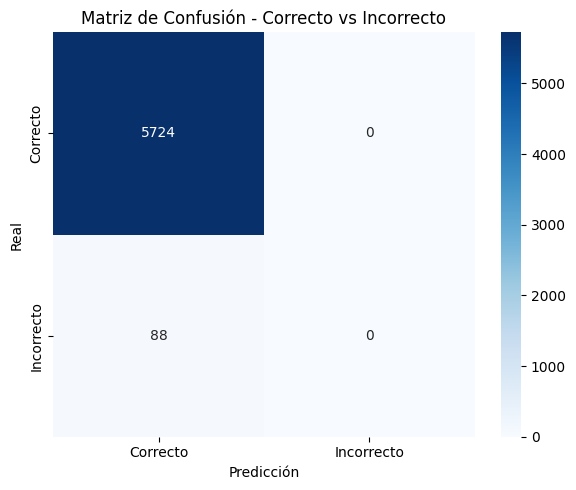


Resumen Global:
  Total de muestras : 5812
  Correctas         : 5724  (98.5%)
  Incorrectas       : 88 (1.5%)


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Generando predicciones detalladas...")
predictions = model.predict(test_gen)
y_pred = np.argmax(predictions, axis=1)
y_true = test_gen.classes

# --- CONVERSIÓN A BINARIO: Correcto (1) vs Incorrecto (0) ---
y_true_bin = (y_true == y_pred).astype(int)
y_pred_bin = np.ones(len(y_pred), dtype=int)  # El modelo "predijo" para cada muestra

cm = confusion_matrix(y_true_bin, y_pred_bin, labels=[1, 0])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Correcto', 'Incorrecto'],
            yticklabels=['Correcto', 'Incorrecto'])
plt.title('Matriz de Confusión - Correcto vs Incorrecto')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()

save_path = FIGURES_DIR / "matriz_confusion.png"
plt.savefig(save_path, dpi=300)
plt.show()

# --- MÉTRICAS GLOBALES ---
total = len(y_true)
correctos = np.sum(y_true == y_pred)
incorrectos = total - correctos

print(f"\nResumen Global:")
print(f"  Total de muestras : {total}")
print(f"  Correctas         : {correctos}  ({correctos/total*100:.1f}%)")
print(f"  Incorrectas       : {incorrectos} ({incorrectos/total*100:.1f}%)")

In [20]:
import numpy as np

# Buscamos dónde la predicción no coincide con la realidad
errors = np.where(y_pred != y_true)[0]

print(f"\nTotal de errores encontrados: {len(errors)} de {len(y_true)} imágenes reales.")
print(f"   Precisión Global (Accuracy): {1 - len(errors)/len(y_true):.2%}")


Total de errores encontrados: 88 de 5812 imágenes reales.
   Precisión Global (Accuracy): 98.49%


In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Tu modelo conceptual
modelo_didactico = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(224, 224, 3), name='Convolucion_1'),
    MaxPooling2D(pool_size=(2, 2), name='Pooling_1'),
    Conv2D(64, kernel_size=(3, 3), activation='relu', name='Convolucion_2'),
    MaxPooling2D(pool_size=(2, 2), name='Pooling_2'),
    Flatten(name='Aplanado'),
    Dense(128, activation='relu', name='Capa_Densa_Oculta'),
    Dense(30, activation='softmax', name='Clasificacion_Final')
])

# Generar el diagrama nativo
tf.keras.utils.plot_model(
    modelo_didactico, 
    to_file=FIGURES_DIR / "diagrama_cnn_didactico.png", 
    show_shapes=True, 
    show_layer_names=True,
    dpi=96 # Ajusta la resolución
)

You must install pydot (`pip install pydot`) for `plot_model` to work.


/home/lordaguakate/Documentos/GitHub/EntrenamientoIA/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

# 2. Construimos el modelo usando la API Funcional (A prueba de fallos en Keras 3)
entradas = Input(shape=(224, 224, 3), name='Imagen_Entrada')

x = Conv2D(32, kernel_size=(3, 3), activation='relu', name='Convolucion_1')(entradas)
x = MaxPooling2D(pool_size=(2, 2), name='Pooling_1')(x)

x = Conv2D(64, kernel_size=(3, 3), activation='relu', name='Convolucion_2')(x)
x = MaxPooling2D(pool_size=(2, 2), name='Pooling_2')(x)

x = Flatten(name='Aplanado')(x)
x = Dense(128, activation='relu', name='Capa_Densa_Oculta')(x)

salidas = Dense(30, activation='softmax', name='Clasificacion_Final')(x)

# Ensamblamos el modelo
modelo_didactico = Model(inputs=entradas, outputs=salidas)

# 3. Generar el diagrama
tf.keras.utils.plot_model(
    modelo_didactico, 
    to_file=FIGURES_DIR / "diagrama_cnn_funcional.png", 
    show_shapes=True, 
    show_layer_names=True,
    dpi=96 
)

print(f"¡Listo! El diagrama debería estar guardado en: {FIGURES_DIR / 'diagrama_cnn_funcional.png'}")

You must install pydot (`pip install pydot`) for `plot_model` to work.
¡Listo! El diagrama debería estar guardado en: ../reports/figures/diagrama_cnn_funcional.png



Mostrando 5 ejemplos de clasificaciones incorrectas:


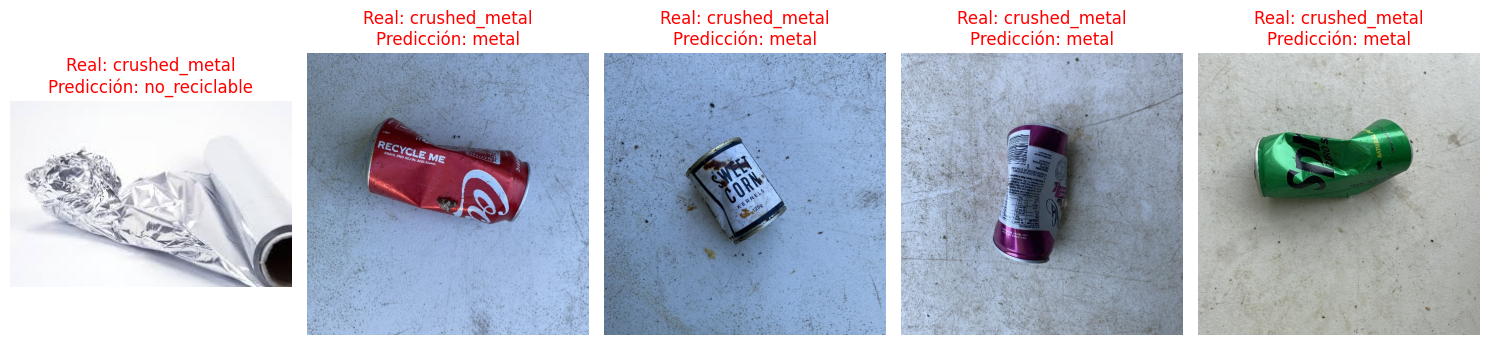

In [23]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Extraemos las rutas de los archivos reales y los nombres de las clases
filepaths = test_gen.filepaths
class_names = list(test_gen.class_indices.keys())

# Cuántos errores queremos ver en pantalla (máximo 5 para no saturar)
num_errores_a_mostrar = min(5, len(errors))

if num_errores_a_mostrar > 0:
    print(f"\nMostrando {num_errores_a_mostrar} ejemplos de clasificaciones incorrectas:")
    plt.figure(figsize=(15, 5))
    
    for i in range(num_errores_a_mostrar):
        # Índice del error en el dataset
        idx = errors[i]
        
        # Ruta de la imagen real
        img_path = filepaths[idx]
        
        # Etiquetas correspondientes
        etiqueta_real = class_names[y_true[idx]]
        etiqueta_predicha = class_names[y_pred[idx]]
        
        # Cargar y mostrar la imagen
        img = mpimg.imread(img_path)
        plt.subplot(1, num_errores_a_mostrar, i + 1)
        plt.imshow(img)
        
        # El título mostrará en rojo la equivocación
        plt.title(f"Real: {etiqueta_real}\nPredicción: {etiqueta_predicha}", color='red')
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()
else:
    print("¡Excelente trabajo! El modelo no cometió ningún error en el set de pruebas.")

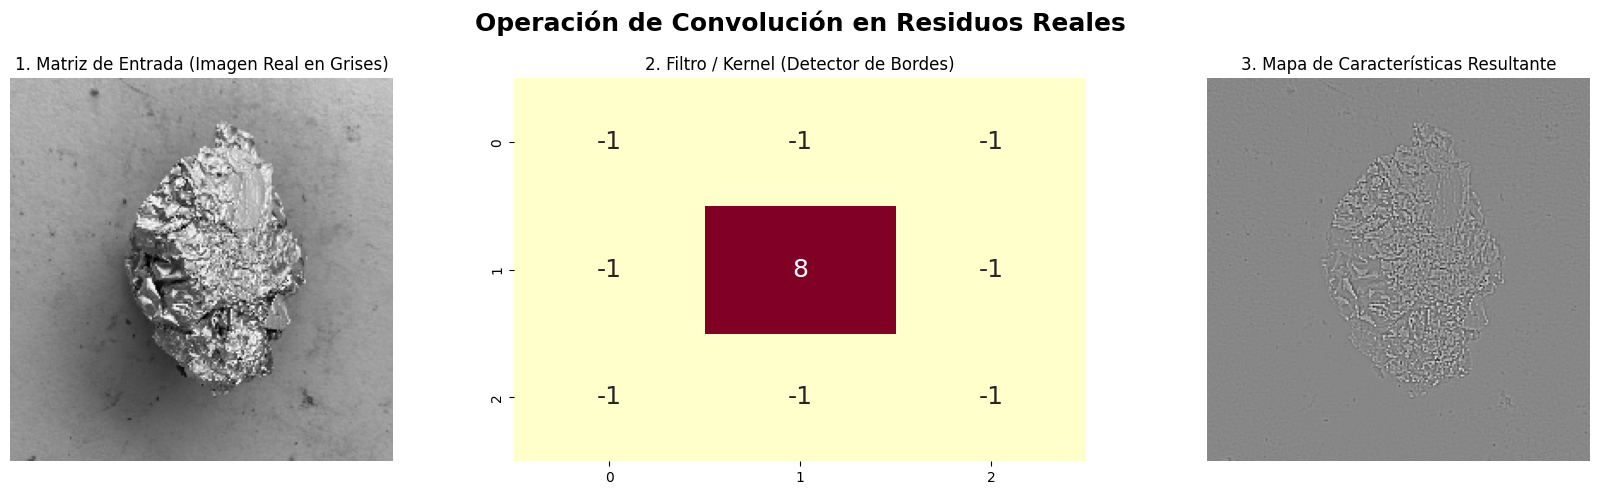

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import convolve2d
from tensorflow.keras.preprocessing import image

# Asumimos que 'filepaths' ya existe de las celdas anteriores (las rutas de tu set de prueba)
# Tomaremos la primera imagen de tu dataset para el ejemplo
ruta_imagen_real = filepaths[0] 

# 1. Cargar la imagen REAL
# La convertimos a escala de grises porque las convoluciones espaciales básicas 
# se explican mejor en 2D (un solo canal de color, donde 0 es negro y 255 es blanco).
img_real = image.load_img(ruta_imagen_real, target_size=(224, 224), color_mode="grayscale")
imagen_matriz = image.img_to_array(img_real).squeeze() # La convertimos en una matriz matemática 2D

# 2. Definir el Filtro (Kernel)
# En lugar de un detector de líneas verticales, usaremos un clásico "Detector de Bordes" (Laplaciano).
# Este filtro es experto en encontrar cambios bruscos de color/luz (es decir, las siluetas de los objetos).
filtro_bordes = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

# 3. Aplicar la operación matemática de convolución
# La función desliza el filtro de 3x3 por toda la matriz de la imagen de 224x224, 
# multiplicando y sumando los valores píxel por píxel.
resultado_real = convolve2d(imagen_matriz, filtro_bordes, mode='valid')

# 4. Graficar el proceso
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- GRÁFICA 1: LA MATRIZ DE ENTRADA (IMAGEN REAL) ---
# ¿Qué hace?: Muestra los datos crudos que entran a la capa neuronal. 
# Cada punto de luz es un número en la matriz. Aquí vemos la forma original del objeto.
axes[0].imshow(imagen_matriz, cmap="gray")
axes[0].set_title("1. Matriz de Entrada (Imagen Real en Grises)")
axes[0].axis('off')

# --- GRÁFICA 2: EL FILTRO / KERNEL ---
# ¿Qué hace?: Representa los "pesos" que la red neuronal aprendería. 
# Es la pequeña matriz de 3x3 que actúa como una "lupa" buscando un patrón específico. 
# Como es muy pequeña, sí podemos imprimir sus números internos (annot=True).
sns.heatmap(filtro_bordes, annot=True, fmt="d", cmap="YlOrRd", cbar=False, ax=axes[1], annot_kws={"size": 18})
axes[1].set_title("2. Filtro / Kernel (Detector de Bordes)")

# --- GRÁFICA 3: EL MAPA DE CARACTERÍSTICAS (RESULTADO) ---
# ¿Qué hace?: Es el producto final. Muestra qué partes de la imagen se "activaron" 
# al pasarles el filtro. Notarás que el fondo desaparece casi por completo y 
# solo brillan las siluetas, arrugas y contornos del plástico o metal. 
# ¡Esto es lo que realmente "ve" y analiza tu IA!
axes[2].imshow(resultado_real, cmap="gray")
axes[2].set_title("3. Mapa de Características Resultante")
axes[2].axis('off')

plt.suptitle("Operación de Convolución en Residuos Reales", fontsize=18, fontweight='bold')
plt.tight_layout()

save_path = FIGURES_DIR / "mapa_convolucion_real.png"
plt.savefig(save_path, dpi=300)

plt.show()